# 0. 설정

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyfixest as pf
import yfinance as yf

START = "2022-06-01"             # 가격 시작일 (2020-06으로 당기면 이벤트가 늘지만 코로나 뉴스 교란 주의)
LIMIT = 25                       # get_earnings_dates 요청 행 수 (yfinance는 25/50/100 단위)
PRE, POST = 10, 10               # Method B(교차확인) 윈도우 [-10, +10]
WIN_A = 10                       # DiD 윈도우 [-10, +10] 이면서 대조군 규칙(자기 발표 없는 거래일 수)
BASE = (-60, -21)                # 비정상 거래량 기준구간
BENCH = "XLV"                    # 시장조정용 벤치마크
CONTROL_MODE = "other_subgroup"  # "other_subgroup" | "same_subgroup" | "any"
MIN_CTRL = 2                     # 이벤트당 최소 대조군 수
INCLUDE_UNKNOWN_TIME = False     # 발표 시각 불명(00:00) 행 포함 여부
T0_OVERRIDE = {}                 # {("LLY", "2025-08-07"): "BMO"}  시각 불명 행 수동 지정 (BMO/AMC)
EXCLUDE = set()                  # {("VRTX", "2025-05-05")}  교란 이벤트 확인 후 채우기 (셀 10 참고)

SUBGROUP = {
    **dict.fromkeys(["LLY", "MRK", "PFE", "BMY", "JNJ"], "pharma"),
    **dict.fromkeys(["ABBV", "AMGN", "GILD", "VRTX", "REGN", "BIIB"], "biotech"),
    **dict.fromkeys(["TMO", "DHR", "IQV", "CRL", "A", "WAT"], "tools"),
}
TICKERS = list(SUBGROUP)

# 1. 데이터 수집 (yfinance)

In [ ]:
def get_events(tk, limit=LIMIT):
    df = yf.Ticker(tk).get_earnings_dates(limit=limit)
    df = df.dropna(subset=["Reported EPS"]).reset_index()
    df = df.rename(columns={"Earnings Date": "ann_dt", "EPS Estimate": "eps_est",
                            "Reported EPS": "eps_act"})
    df["ticker"] = tk
    return df[["ticker", "ann_dt", "eps_est", "eps_act"]]


events = pd.concat([get_events(t) for t in TICKERS], ignore_index=True)

px = yf.download(TICKERS + ["SPY", "XLV"], start=START, auto_adjust=True, progress=False)
close, vol = px["Close"], px["Volume"]
cal = close.index  # 거래일 달력


def to_t0(ts):
    """장 마감(16:00 ET) 이후 발표면 다음 거래일을 t=0으로"""
    ts = ts.tz_convert("America/New_York")
    day = pd.Timestamp(ts.date())
    pos = cal.searchsorted(day, side="right" if ts.hour >= 16 else "left")
    return cal[pos] if pos < len(cal) else pd.NaT


def price_at(tk, t0, k):
    if pd.isna(t0):
        return np.nan
    i = cal.get_loc(t0) + k
    return close[tk].iloc[i] if 0 <= i < len(cal) else np.nan


events["t0"] = events["ann_dt"].apply(to_t0)
events["time_unknown"] = events["ann_dt"].dt.hour.eq(0)       # 시각 정보 없는 행
events["sue"] = (events["eps_act"] - events["eps_est"]) / \
    events.apply(lambda r: price_at(r.ticker, r.t0, -2), axis=1)
print(f"수집: {len(events)}개 이벤트 (기업당 평균 {len(events) / len(TICKERS):.0f}개), "
      f"시각 불명 {int(events['time_unknown'].sum())}개")

수집: 408개 이벤트 (기업당 평균 24개), 시각 불명 0개


# 2. 이벤트 정리 + 서프라이즈(SUE) 정의

In [ ]:
def t0_from_date(date_str, session):
    pos = cal.searchsorted(pd.Timestamp(date_str), side="right" if session == "AMC" else "left")
    return cal[pos] if pos < len(cal) else pd.NaT


ev = events.copy()
ev["subgroup"] = ev["ticker"].map(SUBGROUP)
ev["ann_date"] = ev["ann_dt"].dt.strftime("%Y-%m-%d")
for i, r in ev.iterrows():
    if (r.ticker, r.ann_date) in T0_OVERRIDE:
        ev.at[i, "t0"] = t0_from_date(r.ann_date, T0_OVERRIDE[(r.ticker, r.ann_date)])
        ev.at[i, "time_unknown"] = False

n0 = len(ev)
ev = ev.dropna(subset=["t0"])
if not INCLUDE_UNKNOWN_TIME:
    ev = ev[~ev["time_unknown"]]
ev = ev[[(t, d) not in EXCLUDE for t, d in zip(ev.ticker, ev.ann_date)]]
ev = ev[np.isfinite(ev["sue"])]
pos = cal.get_indexer(ev["t0"])
ev = ev[(pos + BASE[0] >= 0) & (pos + max(POST, WIN_A) < len(cal))].reset_index(drop=True)
ev["event_id"] = np.arange(len(ev))

# --- 회사 기준 서프라이즈 강도 (연속형) ---
# 1) 가격 스케일링 SUE를 "그 기업 자신의 SUE 표준편차"로 나눔 → 기업 간 스케일 차이 제거
# 2) 0은 그대로 "컨센서스 부합"을 뜻함 (평균을 빼지 않음). +: 예상보다 커짐, −: 작아짐
x = ev["sue"] / ev.groupby("ticker")["sue"].transform("std")
ev["sue_firm"] = x.clip(*x.quantile([0.01, 0.99]))            # 1/99% winsorize
ev["sue_firm_c"] = ev["sue_firm"] - ev["sue_firm"].mean()    # 평균 제거 버전: β를 "평균 발표 효과"로 읽기 위함
ev["sue_abs"] = ev["sue_firm"].abs()                          # 서프라이즈 크기(방향 무관): 거래량용
ev["sue_pos"] = ev["sue_firm"].clip(lower=0)                  # 비대칭 점검용: 예상보다 커진 부분
ev["sue_neg"] = ev["sue_firm"].clip(upper=0)                  # 비대칭 점검용: 예상보다 작아진 부분
# 비교용: 시장(전체 표본) 기준 표준화
w = ev["sue"].clip(*ev["sue"].quantile([0.01, 0.99]))
ev["sue_pooled"] = (w - w.mean()) / w.std()
INT_COLS = ["sue_firm", "sue_firm_c", "sue_abs", "sue_pos", "sue_neg", "sue_pooled"]

print(f"전체 {n0}개 → 사용 가능 {len(ev)}개")
print(ev.groupby("subgroup").size().rename("이벤트 수"))
print(f"SUE<0(예상보다 작아짐) 이벤트: {int((ev['sue'] < 0).sum())}개 / {len(ev)}개")
print(ev["sue_firm"].describe().round(3))

전체 408개 → 사용 가능 272개
subgroup
biotech    96
pharma     80
tools      96
Name: 이벤트 수, dtype: int64
SUE<0(예상보다 작아짐) 이벤트: 24개 / 272개
count    272.000
mean       1.118
std        1.020
min       -1.269
25%        0.367
50%        0.982
75%        1.807
max        3.659
Name: sue_firm, dtype: float64


# 3. 패널 빌더 + 추정 함수

In [ ]:
def build_panel(tk, t0, eid, k_min, k_max):
    """한 기업 × 한 이벤트의 [k_min, k_max] 패널. 기준시점 t=-1."""
    i0 = cal.get_loc(t0)
    idx = np.arange(i0 + k_min, i0 + k_max + 1)
    p, b = close[tk].iloc[idx].values, close[BENCH].iloc[idx].values
    base_p, base_b = close[tk].iloc[i0 - 1], close[BENCH].iloc[i0 - 1]
    v = vol[tk].replace(0, np.nan)
    base_vol = np.log(v.iloc[i0 + BASE[0]: i0 + BASE[1] + 1]).mean()
    out = pd.DataFrame({
        "event_id": eid, "ticker": tk, "rel_t": np.arange(k_min, k_max + 1),
        "cr": np.log(p / base_p),
        "cr_bench": np.log(b / base_b),
        "abvol": np.log(v.iloc[idx].values) - base_vol,
    })
    out["car"] = out["cr"] - out["cr_bench"]
    return out


# 기업별 "자기 발표 위치" (필터 전 전체 이벤트 기준 → 대조군 오염 방지)
own_pos = {t: np.sort(cal.get_indexer(g["t0"].dropna())) for t, g in events.groupby("ticker")}


def clean_controls(focal, sub, i0, mode, win):
    cands = [t for t in TICKERS if t != focal]
    if mode == "other_subgroup":
        cands = [t for t in cands if SUBGROUP[t] != sub]
    elif mode == "same_subgroup":
        cands = [t for t in cands if SUBGROUP[t] == sub]
    empty = np.array([], dtype=int)
    return [t for t in cands if not np.any(np.abs(own_pos.get(t, empty) - i0) <= win)]


def stack_A(ev_use, mode=None, win=None, shift=0):
    """이벤트마다 {처치 1개 + 깨끗한 대조군 k개}를 쌓은 패널. 대조군의 서프라이즈 값은 0."""
    mode, win = mode or CONTROL_MODE, win or WIN_A
    frames = []
    for r in ev_use.itertuples():
        i0 = cal.get_loc(r.t0) + shift
        t0 = cal[i0]
        ctrl = clean_controls(r.ticker, r.subgroup, i0, mode, win)
        if len(ctrl) < MIN_CTRL:
            continue
        f = [build_panel(r.ticker, t0, r.event_id, -win, win)
             .assign(treat=1, **{c: getattr(r, c) for c in INT_COLS})]
        f += [build_panel(c, t0, r.event_id, -win, win)
              .assign(treat=0, **{c: 0.0 for c in INT_COLS}) for c in ctrl]
        d = pd.concat(f)
        d["focal"] = r.ticker
        frames.append(d)
    if not frames:
        raise RuntimeError(f"[{mode}, win={win}] 깨끗한 대조군이 있는 이벤트가 없음")
    df = pd.concat(frames, ignore_index=True)
    df["firm_event"] = df["event_id"].astype(str) + "_" + df["ticker"]
    df["event_relt"] = df["event_id"].astype(str) + "_" + df["rel_t"].astype(str)
    return df


def es_cont(df, ycol, cols, fe, kmin, kmax, cluster="focal", beta=True):
    """rel_t 더미 × (처치, 처치×서프라이즈) 이벤트스터디. k=-1 기준.
    반환: {"beta": 발표 효과, <col>: 그 서프라이즈 변수 1단위당 추가 효과} (각각 k, est, lo, hi)"""
    d = df.dropna(subset=[ycol]).copy()
    rhs, kmap = [], {}
    for k in range(kmin, kmax + 1):
        if k == -1:
            continue
        tag = f"{'m' if k < 0 else 'p'}{abs(k)}"
        ind = (d["rel_t"] == k).astype(float) * d["treat"]
        if beta:
            d[f"b_{tag}"] = ind
            rhs.append(f"b_{tag}")
            kmap[f"b_{tag}"] = ("beta", k)
        for j, c in enumerate(cols):
            d[f"g{j}_{tag}"] = ind * d[c]
            rhs.append(f"g{j}_{tag}")
            kmap[f"g{j}_{tag}"] = (c, k)
    fit = pf.feols(f"{ycol} ~ {' + '.join(rhs)} | {fe}", data=d, vcov={"CRV1": cluster})
    t = fit.tidy().reset_index()
    t = t.rename(columns={t.columns[0]: "coef", "Estimate": "est", "2.5%": "lo", "97.5%": "hi"})
    t["var"] = t["coef"].map(lambda c: kmap[c][0])
    t["k"] = t["coef"].map(lambda c: kmap[c][1])
    ref = pd.DataFrame({"k": [-1], "est": [0.0], "lo": [0.0], "hi": [0.0]})
    return {v: pd.concat([g[["k", "est", "lo", "hi"]], ref]).sort_values("k").reset_index(drop=True)
            for v, g in t.groupby("var")}


def plot_es(t, title, ylabel, scale=1.0):
    t = t.assign(est=t.est * scale, lo=t.lo * scale, hi=t.hi * scale)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.errorbar(t["k"], t["est"], yerr=[t["est"] - t["lo"], t["hi"] - t["est"]], fmt="o-", capsize=3)
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(-0.5, color="gray", ls="--", lw=0.8)
    ax.set_xlabel("relative trading day (k)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def pick(t, ks=(-2, 0, 1, 5, 10), scale=100):
    out = t[t["k"].isin(ks)].copy()
    out[["est", "lo", "hi"]] = (out[["est", "lo", "hi"]] * scale).round(3)
    return out.set_index("k")

# 4. 메인: stacked DiD(발표 여부) × 연속 SUE

[other_subgroup, ±10일] 사용 이벤트 119/272, 이벤트당 평균 대조군 4.1개


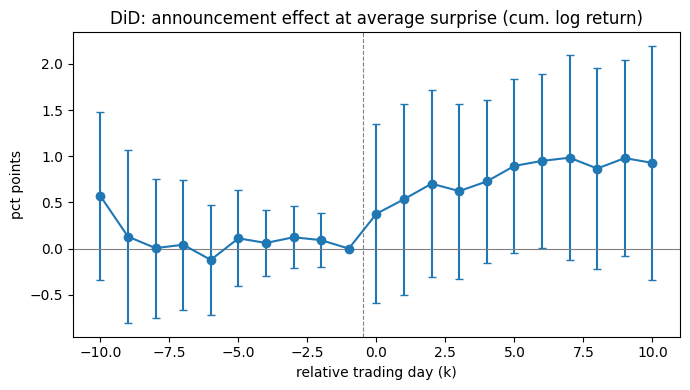

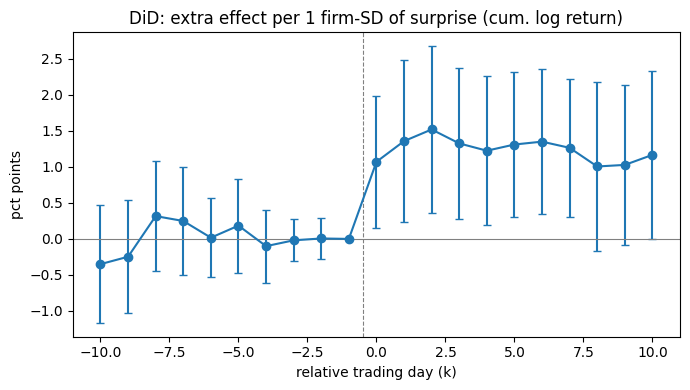

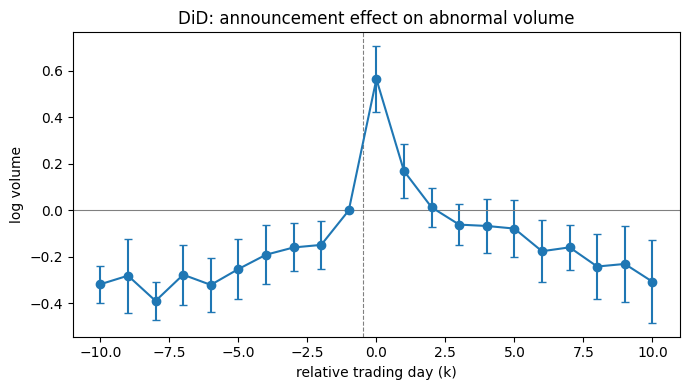

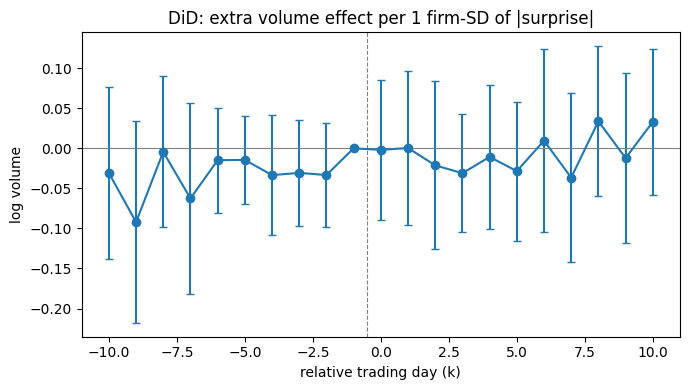


[수익률, %p] β_부합=SUE 0일 때 / β_평균=평균 SUE일 때 / γ=1SD당 추가
    beta_부합               beta_평균                gamma              
        est     lo     hi     est     lo     hi    est     lo     hi
k                                                                   
-2    0.085 -0.394  0.563   0.092 -0.203  0.386  0.006 -0.275  0.287
 0   -0.820 -2.223  0.584   0.377 -0.592  1.346  1.071  0.153  1.988
 1   -0.983 -2.673  0.707   0.534 -0.499  1.567  1.358  0.235  2.482
 5   -0.570 -1.967  0.828   0.895 -0.048  1.838  1.311  0.303  2.319
 10  -0.376 -2.658  1.905   0.928 -0.336  2.191  1.167 -0.004  2.337

사전기간 계수(0 근처여야 평행추세 OK, %p):
    beta_평균                gamma              
        est     lo     hi    est     lo     hi
k                                             
-10   0.569 -0.344  1.482 -0.350 -1.166  0.466
-8    0.005 -0.746  0.757  0.317 -0.444  1.077
-6   -0.122 -0.719  0.475  0.017 -0.528  0.562
-4    0.061 -0.297  0.420 -0.100 -0.607  0.406
-3    0.123 -0.215  0.461 -0.020 -0

In [ ]:
FE_A = "firm_event + event_relt"
stack = stack_A(ev)
print(f"[{CONTROL_MODE}, ±{WIN_A}일] 사용 이벤트 {stack['event_id'].nunique()}/{len(ev)}, "
      f"이벤트당 평균 대조군 {(stack.groupby('event_id')['ticker'].nunique() - 1).mean():.1f}개")

# (a) 수익률: β(컨센서스 부합 시 발표 효과), γ(기업 내 SUE 1SD당 추가 효과)
r_cr = es_cont(stack, "cr", ["sue_firm"], FE_A, -WIN_A, WIN_A)
# (b) 평균 서프라이즈에서의 발표 효과를 보려면 SUE에서 평균을 뺀 버전의 β를 사용
r_cr_c = es_cont(stack, "cr", ["sue_firm_c"], FE_A, -WIN_A, WIN_A)
# (c) 거래량: 서프라이즈 크기(|SUE|)와의 관계
r_vol = es_cont(stack, "abvol", ["sue_abs"], FE_A, -WIN_A, WIN_A)

plot_es(r_cr_c["beta"], "DiD: announcement effect at average surprise (cum. log return)", "pct points", 100)
plot_es(r_cr["sue_firm"], "DiD: extra effect per 1 firm-SD of surprise (cum. log return)", "pct points", 100)
plot_es(r_vol["beta"], "DiD: announcement effect on abnormal volume", "log volume")
plot_es(r_vol["sue_abs"], "DiD: extra volume effect per 1 firm-SD of |surprise|", "log volume")

print("\n[수익률, %p] β_부합=SUE 0일 때 / β_평균=평균 SUE일 때 / γ=1SD당 추가")
print(pd.concat({"beta_부합": pick(r_cr["beta"]), "beta_평균": pick(r_cr_c["beta"]),
                 "gamma": pick(r_cr["sue_firm"])}, axis=1).to_string())
print("\n사전기간 계수(0 근처여야 평행추세 OK, %p):")
print(pd.concat({"beta_평균": pick(r_cr_c["beta"], ks=(-10, -8, -6, -4, -3, -2)),
                "gamma": pick(r_cr["sue_firm"], ks=(-10, -8, -6, -4, -3, -2))}, axis=1).to_string())
print("\n[거래량, log] β / γ(|SUE|)")
print(pd.concat({"beta": pick(r_vol["beta"], scale=1), "gamma_abs": pick(r_vol["sue_abs"], scale=1)},
                axis=1).to_string())

# 5. 강건성: 회사 기준 vs 시장 기준, 비대칭, 하위그룹

In [ ]:
rows = []


def add(name, res, var, n):
    t = res[var].set_index("k")
    for k in (0, 1, 5):
        rows.append({"spec": name, "n_events": n, "k": k, "gamma": t.loc[k, "est"] * 100,
                     "lo": t.loc[k, "lo"] * 100, "hi": t.loc[k, "hi"] * 100})


n_all = stack["event_id"].nunique()
add("회사 기준 SUE (메인)", r_cr, "sue_firm", n_all)
add("시장 기준 SUE (비교용)", es_cont(stack, "cr", ["sue_pooled"], FE_A, -WIN_A, WIN_A), "sue_pooled", n_all)

r_asym = es_cont(stack, "cr", ["sue_pos", "sue_neg"], FE_A, -WIN_A, WIN_A)   # 예상보다 커짐 vs 작아짐
add("비대칭: 예상보다 커진 부분(+)", r_asym, "sue_pos", n_all)
add("비대칭: 예상보다 작아진 부분(−)", r_asym, "sue_neg", n_all)

for g in ["pharma", "biotech", "tools"]:
    try:
        s = stack_A(ev[ev["subgroup"] == g])
        add(f"{g}만", es_cont(s, "cr", ["sue_firm"], FE_A, -WIN_A, WIN_A), "sue_firm", s["event_id"].nunique())
    except RuntimeError as e:
        print(e)
print(pd.DataFrame(rows).round(3).to_string(index=False))
# 비대칭 행: "+"와 "−"의 γ가 크게 다르면 서프라이즈 방향에 따라 반응이 비대칭이라는 뜻 (SUE<0 이벤트가 적으면 CI 넓음)


               spec  n_events  k  gamma     lo    hi
     회사 기준 SUE (메인)       119  0  1.071  0.153 1.988
     회사 기준 SUE (메인)       119  1  1.358  0.235 2.482
     회사 기준 SUE (메인)       119  5  1.311  0.303 2.319
    시장 기준 SUE (비교용)       119  0  0.404 -0.531 1.339
    시장 기준 SUE (비교용)       119  1  0.731 -0.273 1.735
    시장 기준 SUE (비교용)       119  5  0.104 -0.853 1.062
 비대칭: 예상보다 커진 부분(+)       119  0  1.108  0.045 2.170
 비대칭: 예상보다 커진 부분(+)       119  1  1.301  0.041 2.562
 비대칭: 예상보다 커진 부분(+)       119  5  1.084 -0.051 2.218
비대칭: 예상보다 작아진 부분(−)       119  0  0.416 -3.172 4.004
비대칭: 예상보다 작아진 부분(−)       119  1  2.367 -2.266 7.000
비대칭: 예상보다 작아진 부분(−)       119  5  5.351  1.516 9.186
            pharma만        24  0  1.365  0.044 2.686
            pharma만        24  1  1.981  0.211 3.751
            pharma만        24  5  2.727  1.183 4.271
           biotech만        61  0  0.854 -0.225 1.933
           biotech만        61  1  1.146 -0.517 2.809
           biotech만        61  5  0.545 -0.845

# 6. 대조군 규칙 EDA: 거래일 수(WIN_A)를 바꾸면 사용 가능한 이벤트가 얼마나 남는가

In [ ]:
rows = []
for win in (3, 5, 7, 10, 15):
    for mode in ("other_subgroup", "any"):
        n_ok, n_c = 0, []
        for r in ev.itertuples():
            c = clean_controls(r.ticker, r.subgroup, cal.get_loc(r.t0), mode, win)
            if len(c) >= MIN_CTRL:
                n_ok += 1
                n_c.append(len(c))
        rows.append({"WIN_A": win, "대조군 풀": mode, "사용 이벤트": f"{n_ok}/{len(ev)}",
                     "이벤트당 평균 대조군": round(float(np.mean(n_c)), 1) if n_c else 0})
print(pd.DataFrame(rows).to_string(index=False))
# 10거래일에서 사용 이벤트가 너무 줄면 WIN_A를 줄이거나 CONTROL_MODE="any"로 바꿔서 셀 4부터 재실행

 WIN_A          대조군 풀  사용 이벤트  이벤트당 평균 대조군
     3 other_subgroup 272/272          7.2
     3            any 272/272         10.1
     5 other_subgroup 257/272          5.4
     5            any 272/272          7.2
     7 other_subgroup 211/272          4.6
     7            any 268/272          5.3
    10 other_subgroup 119/272          4.1
    10            any 186/272          4.1
    15 other_subgroup  29/272          5.3
    15            any  32/272          6.7


# 7. 스필오버 직접 검정: 같은 하위그룹 업체가 발표 기업의 서프라이즈에 따라 움직이는가

In [ ]:
rows = []
for r in ev.itertuples():
    i0 = cal.get_loc(r.t0)
    for p in TICKERS:
        if p == r.ticker or np.any(np.abs(own_pos.get(p, np.array([], dtype=int)) - i0) <= 2):
            continue
        car1 = (np.log(close[p].iloc[i0 + 1] / close[p].iloc[i0 - 1])
                - np.log(close[BENCH].iloc[i0 + 1] / close[BENCH].iloc[i0 - 1])) * 100
        rows.append({"event_id": r.event_id, "same_sub": int(SUBGROUP[p] == r.subgroup),
                     "sue_firm": r.sue_firm, "car1": car1})
sp = pd.DataFrame(rows).dropna()
fit_sp = pf.feols("car1 ~ sue_firm * same_sub", data=sp, vcov={"CRV1": "event_id"})
print(f"동종/타업종 업체-이벤트 쌍: {len(sp)}개")
print(fit_sp.tidy().round(3))
# sue_firm:same_sub ≈ 0이면 같은 하위그룹 업체가 서프라이즈에 따라 같이 움직이지 않음 → 대조군 오염 작음

동종/타업종 업체-이벤트 쌍: 3150개
                   Estimate  Std. Error  t value  Pr(>|t|)   2.5%  97.5%
Coefficient                                                             
Intercept            -0.128       0.090   -1.420     0.157 -0.304  0.049
sue_firm              0.006       0.053    0.107     0.915 -0.099  0.111
same_sub              0.047       0.178    0.262     0.794 -0.304  0.398
sue_firm:same_sub     0.159       0.119    1.339     0.182 -0.075  0.392


# 8. 교차확인 Method B: 대조군 없는 연속처치 (회사 기준 SUE)

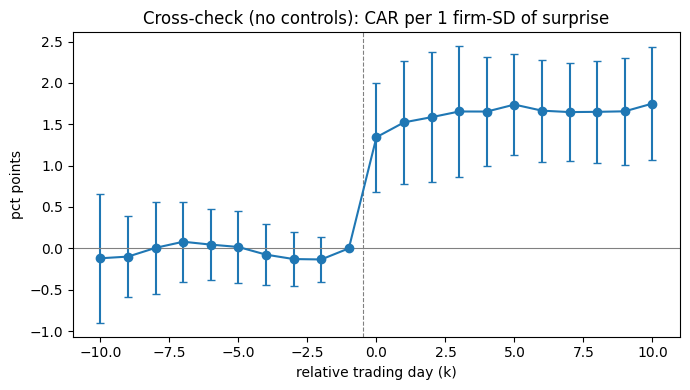

Method B (교차확인) γ, %p:
       est     lo     hi
k                       
-2  -0.134 -0.409  0.141
 0   1.344  0.685  2.004
 1   1.523  0.779  2.267
 5   1.738  1.129  2.348
 10  1.750  1.069  2.431


In [ ]:
frames = []
for r in ev.itertuples():
    frames.append(build_panel(r.ticker, r.t0, r.event_id, -PRE, POST)
                  .assign(treat=1, focal=r.ticker, subgroup=r.subgroup, sue_firm=r.sue_firm))
dfB = pd.concat(frames, ignore_index=True)
dfB["fe_event"] = dfB["event_id"].astype(str)
dfB["sub_relt"] = dfB["subgroup"] + "_" + dfB["rel_t"].astype(str)
r_B = es_cont(dfB, "car", ["sue_firm"], "fe_event + sub_relt", -PRE, POST, beta=False)
plot_es(r_B["sue_firm"], "Cross-check (no controls): CAR per 1 firm-SD of surprise", "pct points", 100)
print("Method B (교차확인) γ, %p:")
print(pick(r_B["sue_firm"]).to_string())
# 셀 4의 γ와 비슷하면 DiD 메인 결과가 대조군 선택에 크게 좌우되지 않는다는 뜻

# 9. 플라시보: 발표일을 30거래일 앞으로 옮겨 재추정

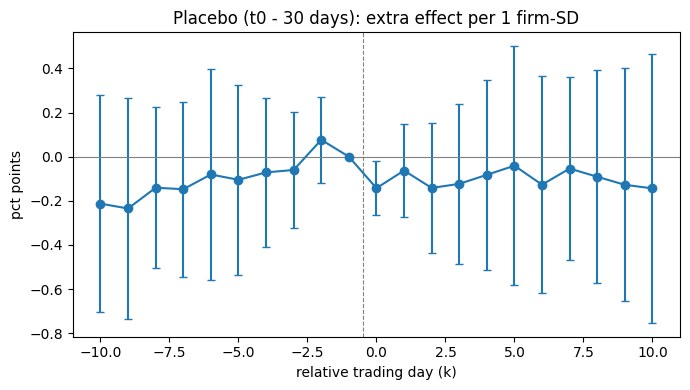

플라시보 γ, %p (전 구간 0 근처여야 함):
       est     lo     hi
k                       
-2   0.076 -0.120  0.272
 0  -0.143 -0.266 -0.020
 1  -0.063 -0.274  0.149
 5  -0.041 -0.582  0.501
 10 -0.144 -0.753  0.466


In [ ]:
SHIFT = -30
ev_p = ev[[cal.get_loc(t) + SHIFT + BASE[0] >= 0 for t in ev["t0"]]]
stack_p = stack_A(ev_p, shift=SHIFT)
r_p = es_cont(stack_p, "cr", ["sue_firm"], FE_A, -WIN_A, WIN_A)
plot_es(r_p["sue_firm"], "Placebo (t0 - 30 days): extra effect per 1 firm-SD", "pct points", 100)
print("플라시보 γ, %p (전 구간 0 근처여야 함):")
print(pick(r_p["sue_firm"]).to_string())

# 10. 교란 이벤트 점검 목록 (FDA·임상·M&A 뉴스 확인용)

In [ ]:
car01 = []
for r in ev.itertuples():
    i0 = cal.get_loc(r.t0)
    car01.append((np.log(close[r.ticker].iloc[i0 + 1] / close[r.ticker].iloc[i0 - 1])
                  - np.log(close[BENCH].iloc[i0 + 1] / close[BENCH].iloc[i0 - 1])) * 100)
chk = ev[["event_id", "ticker", "subgroup", "ann_date", "t0", "sue", "sue_firm"]].copy()
chk["car01_pct"] = car01
chk["abs_car01"] = chk["car01_pct"].abs()
chk["flag_big"] = chk["abs_car01"] > 10
chk["note"] = ""
chk = chk.sort_values("abs_car01", ascending=False)
chk.to_csv("events_confound_check.csv", index=False)
print(f"|CAR[0,+1]| > 10%p 이벤트: {int(chk['flag_big'].sum())}개 / {len(chk)}개 → events_confound_check.csv")
print(chk[chk["flag_big"]][["ticker", "ann_date", "sue_firm", "car01_pct"]].round(2).head(20).to_string(index=False))
# 뉴스 확인 후 교란 이벤트를 EXCLUDE에 넣고 셀 2부터 다시 실행

|CAR[0,+1]| > 10%p 이벤트: 23개 / 272개 → events_confound_check.csv
ticker   ann_date  sue_firm  car01_pct
   CRL 2025-05-07      2.64      20.42
  VRTX 2025-08-04      0.69     -18.36
   WAT 2024-11-01      1.76      18.20
   LLY 2025-08-07      1.33     -17.37
   IQV 2025-07-22      1.40      16.17
     A 2026-05-27      2.38      15.24
   WAT 2026-05-05      2.93      14.19
   LLY 2023-08-08      0.38      14.01
   WAT 2026-02-09      0.12     -13.83
   CRL 2024-08-07      2.12     -13.66
   IQV 2026-07-28      3.24      13.21
  REGN 2025-10-28      1.64      12.58
     A 2024-05-29      0.70     -12.44
  VRTX 2025-05-05     -0.55     -11.97
   MRK 2024-07-30      1.81     -11.90
   LLY 2024-08-08      2.06      11.71
   DHR 2026-07-21      1.17     -11.68
  REGN 2026-07-30      2.52      11.47
   MRK 2025-02-04      0.81     -11.38
   CRL 2026-08-05      1.42      11.14


# 12. 대조군 규칙 민감도 + 같은 이벤트에서 Method B

In [ ]:
# (a) WIN_A(거래일 수)와 대조군 풀을 바꿨을 때 γ가 얼마나 달라지는가
# (b) Method B(대조군 없음)를 "메인 DiD에 쓰인 이벤트"로만 제한 → 표본 차이와 방법 차이를 분리
rows = []


def add12(name, n, t):
    for k in (0, 1, 5):
        rows.append({"spec": name, "n_events": n, "k": k, "gamma": t.loc[k, "est"] * 100,
                     "lo": t.loc[k, "lo"] * 100, "hi": t.loc[k, "hi"] * 100})


for win in (5, 7, 10):
    for mode in ("other_subgroup", "any"):
        try:
            s = stack_A(ev, mode=mode, win=win)
        except RuntimeError:
            continue
        g = es_cont(s, "cr", ["sue_firm"], FE_A, -win, win)["sue_firm"].set_index("k")
        add12(f"DiD  WIN_A={win:>2}  {mode}", s["event_id"].nunique(), g)

ids = stack["event_id"].unique()     # 셀 4에서 쓰인 이벤트 (현재 설정: CONTROL_MODE, WIN_A)
gB = es_cont(dfB[dfB["event_id"].isin(ids)], "car", ["sue_firm"], "fe_event + sub_relt",
             -PRE, POST, beta=False)["sue_firm"].set_index("k")
add12("Method B (메인 DiD와 같은 이벤트)", len(ids), gB)
gB_all = r_B["sue_firm"].set_index("k")
add12("Method B (전체 이벤트)", ev["event_id"].nunique(), gB_all)
print(pd.DataFrame(rows).round(3).to_string(index=False))
# 해석: WIN_A를 줄여도 γ가 비슷하면 결과가 대조군 규칙에 좌우되지 않음.
#       Method B(같은 이벤트)가 DiD의 γ와 비슷하면 DiD가 작게 나온 건 표본 축소 때문이지 방법 때문이 아님.

                         spec  n_events  k  gamma    lo    hi
DiD  WIN_A= 5  other_subgroup       257  0  1.124 0.523 1.725
DiD  WIN_A= 5  other_subgroup       257  1  1.334 0.581 2.087
DiD  WIN_A= 5  other_subgroup       257  5  1.501 0.856 2.145
           DiD  WIN_A= 5  any       272  0  1.209 0.569 1.848
           DiD  WIN_A= 5  any       272  1  1.412 0.628 2.196
           DiD  WIN_A= 5  any       272  5  1.532 0.806 2.257
DiD  WIN_A= 7  other_subgroup       211  0  1.134 0.534 1.734
DiD  WIN_A= 7  other_subgroup       211  1  1.311 0.518 2.104
DiD  WIN_A= 7  other_subgroup       211  5  1.369 0.639 2.099
           DiD  WIN_A= 7  any       268  0  1.195 0.502 1.889
           DiD  WIN_A= 7  any       268  1  1.398 0.559 2.237
           DiD  WIN_A= 7  any       268  5  1.448 0.654 2.243
DiD  WIN_A=10  other_subgroup       119  0  1.071 0.153 1.988
DiD  WIN_A=10  other_subgroup       119  1  1.358 0.235 2.482
DiD  WIN_A=10  other_subgroup       119  5  1.311 0.303 2.319
        